# Seaborn - Statistical Data Visualization

## 1. What is Seaborn

Seaborn is a Python visualization library built on top of Matplotlib. It provides a high-level interface for creating attractive and informative statistical graphics with less code.

**Key Features:**
- Built on top of Matplotlib (more beautiful default styles)
- Works seamlessly with Pandas DataFrames
- Specialized in statistical visualizations
- Less code required compared to Matplotlib
- Built-in themes and color palettes
- Excellent for exploring relationships in data

**When to use Seaborn:**
- When working with Pandas DataFrames
- For statistical analysis and relationships
- When you want beautiful plots with minimal code
- For heatmaps, pair plots, and distribution plots

**Seaborn vs Matplotlib:**
- Seaborn = Higher-level, easier, prettier defaults
- Matplotlib = Lower-level, more control, more code

## 2. Importing Seaborn

- `import seaborn as sns` - Import Seaborn with standard shortcut

**Note:** Seaborn is typically imported as `sns`

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# For displaying plots in Jupyter notebooks
%matplotlib inline

## 3. Seaborn Plot Types

### 3.1 Distribution Plots

Distribution plots show how data is spread across different values, revealing patterns like concentration, spread, and outliers.

---

#### **Histogram - `sns.histplot()`**
Groups data into bins and shows frequency in each range, with optional smooth density curve.

**Syntax:**
```python
sns.histplot(data=df, x='column', bins=30, kde=False, hue='category')
```

**Key Parameters:**
- `data` - DataFrame containing the data
- `x` - Column name to plot
- `bins=30` - Number of ranges to divide data into
- `kde=True` - Add smooth density curve overlay
- `hue='category'` - Color by category (separate distributions)
- `stat='count'` - Y-axis type ('count', 'density', 'probability', 'percent')
- `multiple='layer'` - How to display multiple distributions ('stack', 'dodge', 'fill')
- `color='skyblue'` - Bar color

**Use when:** You want to see frequency distribution in specific ranges.

---

#### **Count Plot - `sns.countplot()`**
Shows count of observations in each category - like a histogram but for categorical data.

**Syntax:**
```python
sns.countplot(data=df, x='category', hue='subcategory')
```

**Key Parameters:**
- `data` - DataFrame
- `x` - Categorical column to count (or use `y` for horizontal bars)
- `hue='subcategory'` - Further split counts by another category
- `order=['A', 'B', 'C']` - Custom order for categories
- `palette='Set2'` - Color scheme
- `orient='v'` - Orientation ('v' vertical, 'h' horizontal)

**What it Shows:**
- Each bar represents one category
- Bar height = number of occurrences of that category
- Perfect for seeing the distribution of categorical variables

**Use when:** You want to count how many times each category appears (e.g., "How many sales per day?", "Count of each product type").

**Example:**
```python
# Count number of restaurant visits per day
sns.countplot(data=tips, x='day', palette='pastel')
# Shows: Thu=62, Fri=19, Sat=87, Sun=76
```

---

#### **KDE Plot - `sns.kdeplot()`**
Smooth probability density curve showing data concentration - no bins, just continuous flow.

**Syntax:**
```python
sns.kdeplot(data=df, x='column', fill=True, hue='category')
```

**Key Parameters:**
- `data` - DataFrame
- `x` - Column to plot (can also use `y` for vertical, or both for 2D density)
- `fill=True` - Fill area under curve
- `hue='category'` - Separate curves by category
- `bw_adjust=1` - Smoothness control (higher = smoother, lower = more detail)
- `multiple='layer'` - Display style ('stack', 'fill')
- `color='coral'` - Curve color

**Density explanation:** Height shows how concentrated/packed data is at each value. Peak = high concentration (many values), valley = low concentration (few values).

**Use when:** You want a smooth view of where data is concentrated without bins.

---

#### **Distribution Plot - `sns.displot()`**
Figure-level function creating complete distribution plots with faceting capabilities.

**Syntax:**
```python
sns.displot(data=df, x='column', kind='hist', col='category')
```

**Key Parameters:**
- `data` - DataFrame
- `x` - Column to plot
- `kind='hist'` - Plot type ('hist', 'kde', 'ecdf')
- `hue='category'` - Color by category
- `col='category'` - Create separate subplot columns by category
- `row='category'` - Create separate subplot rows
- `kde=True` - Add KDE overlay (for histograms)
- `height=5`, `aspect=1.5` - Figure size (width = height × aspect)

**Use when:** You need publication-ready figures or want to compare distributions across multiple categories.

---

#### **Box Plot - `sns.boxplot()`**
Compact summary showing quartiles, median, range, and outliers.

**Syntax:**
```python
sns.boxplot(data=df, x='category', y='value', hue='subcategory')
```

**What it Shows:**
- **Box:** Middle 50% of data (IQR = Q3 - Q1)
- **Line in box:** Median (50th percentile)
- **Top of box:** Q3 (75th percentile)
- **Bottom of box:** Q1 (25th percentile)
- **Whiskers:** Range of normal data (min & max excluding outliers)
  - Top whisker: Max within Q3 + 1.5×IQR
  - Bottom whisker: Min within Q1 - 1.5×IQR
- **Dots:** Outliers (values beyond whiskers)

**Key Parameters:**
- `data` - DataFrame
- `x` - Categorical variable (creates separate boxes)
- `y` - Numerical variable to summarize
- `hue='subcategory'` - Further grouping by color
- `order=['A', 'B']` - Custom category order
- `orient='v'` - Orientation ('v' vertical, 'h' horizontal)
- `showfliers=True` - Show/hide outliers

**Use when:** Comparing distributions across categories and identifying outliers.

---

#### **Violin Plot - `sns.violinplot()`**
Combines KDE shape with box plot statistics - shows both distribution density and quartiles.

**Syntax:**
```python
sns.violinplot(data=df, x='category', y='value', hue='subcategory', split=False)
```

**What it Shows:**
- **Width of violin:** Density at that value (wider = more data concentrated there)
- **White dot:** Median
- **Thick inner bar:** Interquartile range (IQR)
- **Thin line:** Range or confidence interval

**Key Parameters:**
- `data` - DataFrame
- `x` - Categorical variable
- `y` - Numerical variable
- `hue='subcategory'` - Split by another category
- `split=True` - Split violin halves by hue (saves space)
- `inner='box'` - What to show inside ('quartile', 'stick', 'point', None)
- `scale='width'` - Scaling method ('area', 'count', 'width')
- `palette='muted'` - Color scheme

**Use when:** You want both distribution shape (KDE) and statistical summaries (quartiles) together.

---

#### **Understanding KDE (Kernel Density Estimate):**

**What it is:** A smooth curve representing probability density - shows where data is concentrated.

**How it works:**
1. Places a small bell curve (kernel) at each data point
2. Sums all curves together
3. Normalizes so total area under curve = 1

**Key concepts:**
- **Density (y-axis):** How concentrated/packed data is (NOT a count)
- **Peak:** High concentration - many values in that range
- **Valley:** Low concentration - few values in that range
- **Total area = 1:** Represents 100% of the data

**Think of it as:** A smoothed histogram that shows the underlying distribution pattern without arbitrary bins.

**Example:**
```python
sns.histplot(data=df, x='age', kde=True)  # Bars + smooth curve overlay
```

---

#### **Quick Comparison:**

| Plot Type | Data Type | Shows Shape? | Shows Outliers? | Shows Quartiles? | Best For |
|-----------|-----------|--------------|-----------------|------------------|----------|
| Histogram | Numerical | Yes (binned) | No | No | Frequency in ranges |
| Count Plot | Categorical | No | No | No | Category frequencies |
| KDE | Numerical | Yes (smooth) | No | No | Distribution shape |
| Box Plot | Numerical | No | Yes | Yes | Summary stats & outliers |
| Violin | Numerical | Yes (smooth) | Rare | Yes | Shape + stats combined |

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


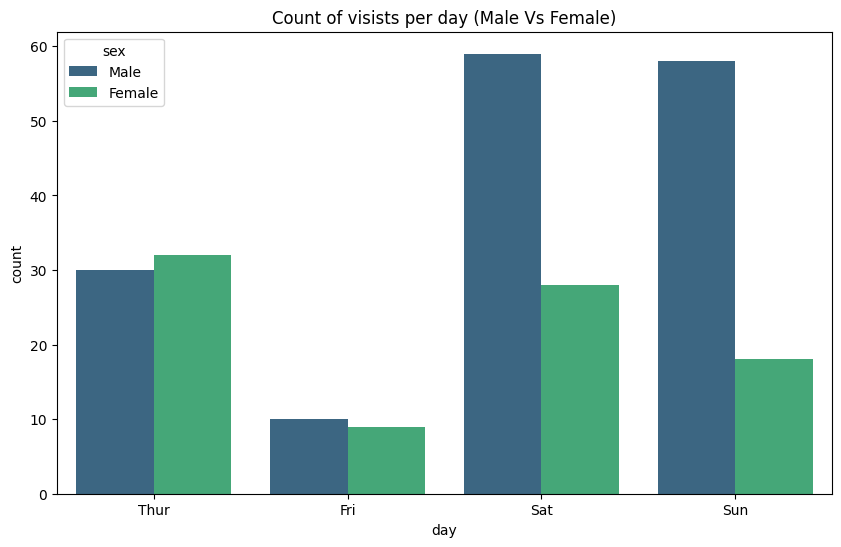

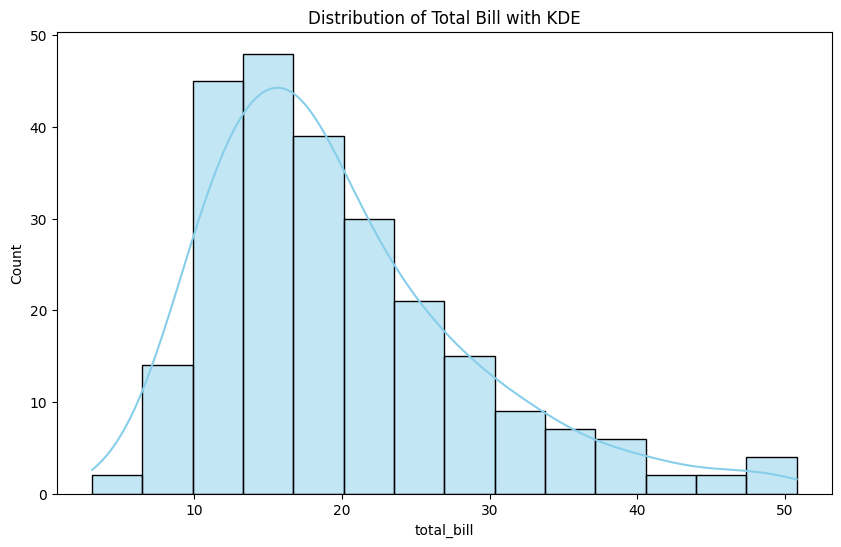

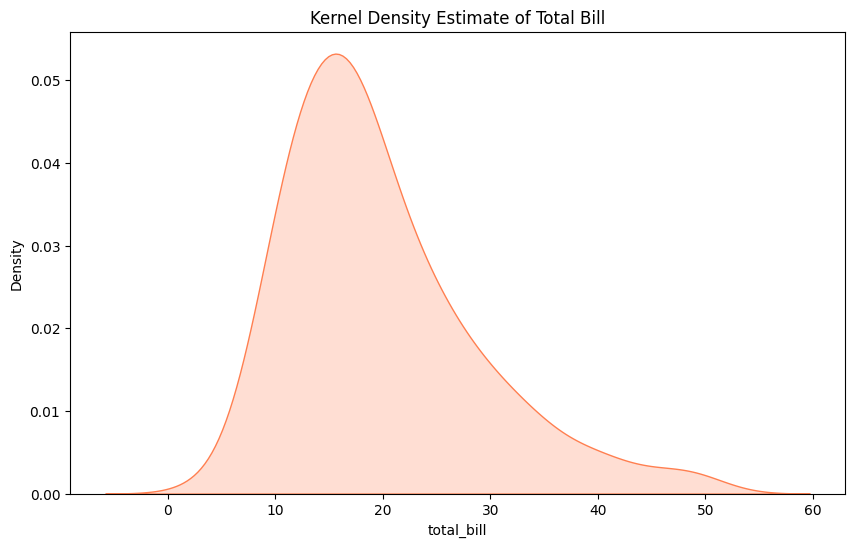

C:\Users\asus\AppData\Local\Temp\ipykernel_55568\4261630274.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', palette='Set2')


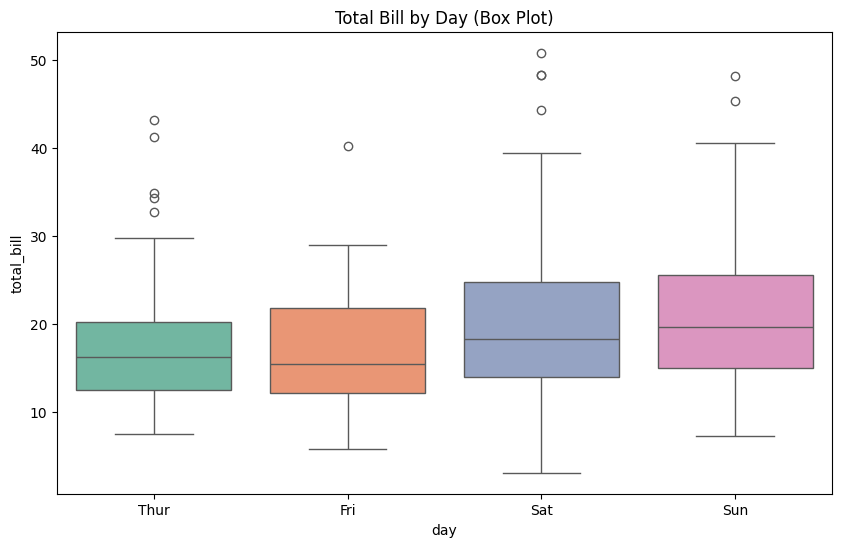

C:\Users\asus\AppData\Local\Temp\ipykernel_55568\4261630274.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='day', y='total_bill', palette='muted')


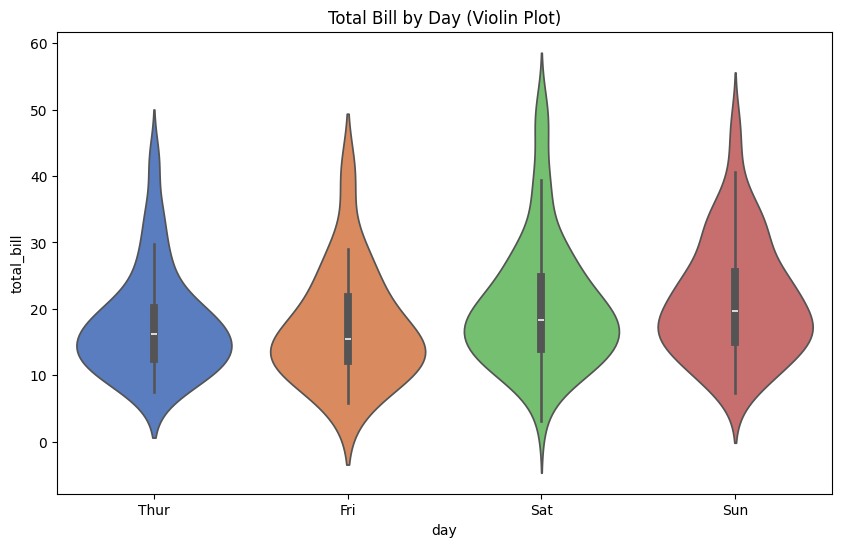

In [3]:
# Create sample data
tips = sns.load_dataset('tips')  # Built-in dataset with restaurant tipping data

print(tips)  # Display the dataset to see its structure

# Count Plot Of number of visits per day
plt.figure(figsize=(10, 6))
sns.countplot(data=tips, x="day", palette="viridis", hue="sex")
# Hue is the further split of sub category- Think of it as group by, will create seperate bars for each sub category
plt.title('Count of visists per day (Male Vs Female)')  # Add title
plt.show()

# Histogram with KDE
plt.figure(figsize=(10, 6))  # Create figure with width=10, height=6 inches
# Plot histogram of total_bill column from tips dataset with KDE overlay
sns.histplot(data=tips, x='total_bill', kde=True, color='skyblue') 
# data=tips: use the tips dataset
# x='total_bill': plot the total_bill column (groups into bins, shows frequency)
# kde=True: add smooth density curve on top of bars
# color='skyblue': make bars skyblue
plt.title('Distribution of Total Bill with KDE')  # Add title
plt.show()  # Display the plot

# KDE Plot
plt.figure(figsize=(10, 6))  # Create new figure
sns.kdeplot(data=tips, x='total_bill', fill=True, color='coral')
# Creates smooth probability density curve without bins
# fill=True: fill area under the curve
# Shows where total_bill values are most concentrated (peaks = common values)
plt.title('Kernel Density Estimate of Total Bill')
plt.show()

# Box Plot
plt.figure(figsize=(10, 6))  # Create new figure
sns.boxplot(data=tips, x='day', y='total_bill', palette='Set2')
# x='day': categorical variable - creates separate box for each day (Thur, Fri, Sat, Sun) - groups data by day
# y='total_bill': numerical variable - shows distribution for each day
# palette='Set2': color scheme for boxes

# What each box shows:
# - Median (line inside box): middle value (50th percentile)
# - Box: middle 50% of data (IQR = Q3 - Q1)
#   - Top of box: Q3 (75th percentile)
#   - Bottom of box: Q1 (25th percentile)
# - Whiskers (lines): range of "normal" data (min & max excluding outliers)
#   - Top whisker: max value within Q3 + 1.5×IQR
#   - Bottom whisker: min value within Q1 - 1.5×IQR
# - Outliers (dots): values beyond whiskers (identified by 1.5×IQR rule)

# Box height (IQR) indicates variability:
# - Tall box = high variability = high standard deviation = data spread out
# - Short box = low variability = low standard deviation = data clustered together

# Median position shows distribution shape:
# - Median centered = symmetric distribution (data balanced between Q1 and Q3)
# - Median near bottom (Q1) = right-skewed (most data points clustered near Q1, only a few high values near Q3)
# - Median near top (Q3) = left-skewed (most data points clustered near Q3, only a few low values near Q1)  
plt.title('Total Bill by Day (Box Plot)')
plt.show()

# Violin Plot
plt.figure(figsize=(10, 6))  # Create new figure
sns.violinplot(data=tips, x='day', y='total_bill', palette='muted')
# Combines box plot + KDE: shows both distribution shape and quartiles
# x='day': separate violin for each day
# y='total_bill': values to plot
# Width of violin = density (wider = more bills at that amount)
# Inner markings show median and IQR
plt.title('Total Bill by Day (Violin Plot)')
plt.show()

### 3.2 Categorical Plots

Categorical plots show relationships between categorical and numerical variables.

**Types:**
- `sns.barplot()` - Bar chart with confidence intervals
- `sns.countplot()` - Count of observations in each category
- `sns.boxplot()` - Distribution across categories
- `sns.violinplot()` - Distribution across categories (more detail)
- `sns.stripplot()` - Scatter plot for categorical data
- `sns.swarmplot()` - Categorical scatter plot with no overlap

C:\Users\asus\AppData\Local\Temp\ipykernel_55568\1325002086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', estimator=np.mean, palette='coolwarm')


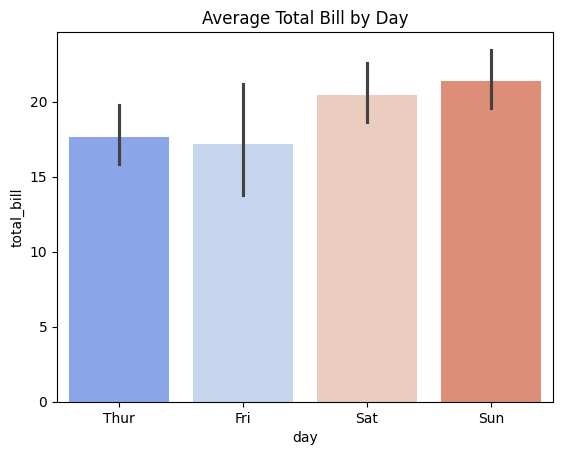

C:\Users\asus\AppData\Local\Temp\ipykernel_55568\1325002086.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tips, x='day', palette='pastel')


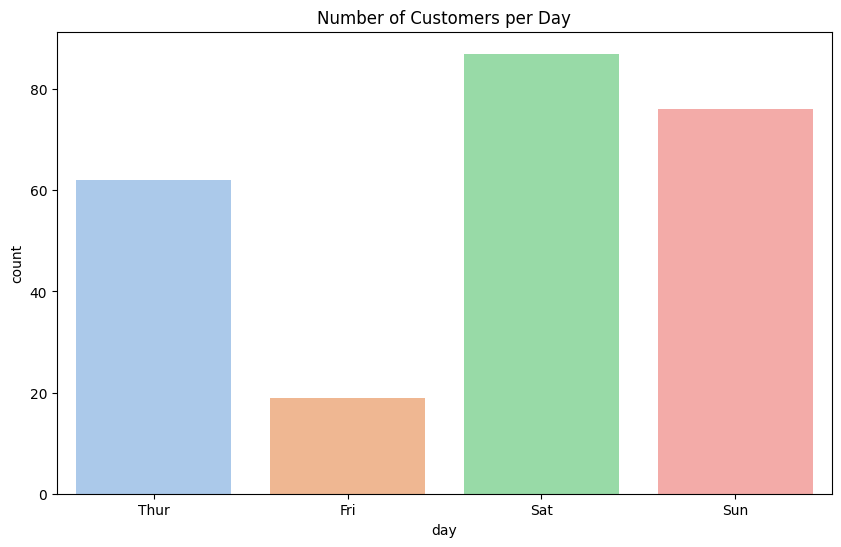

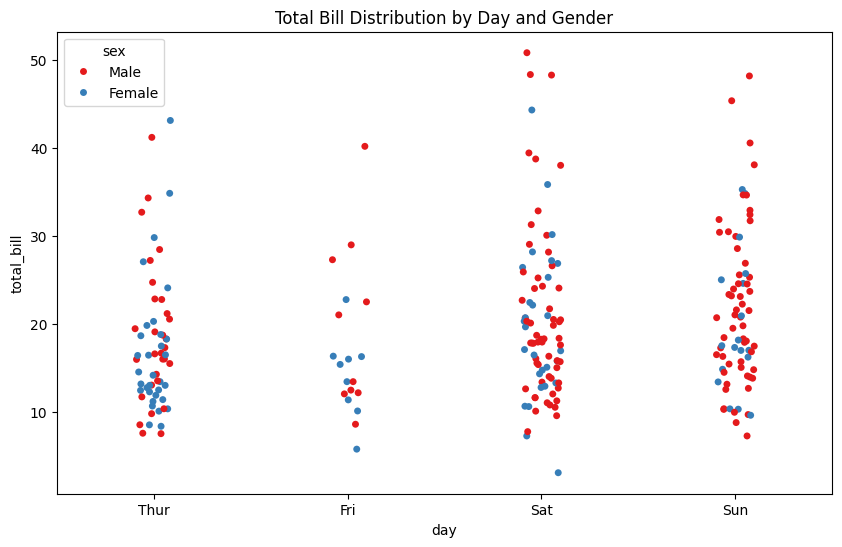

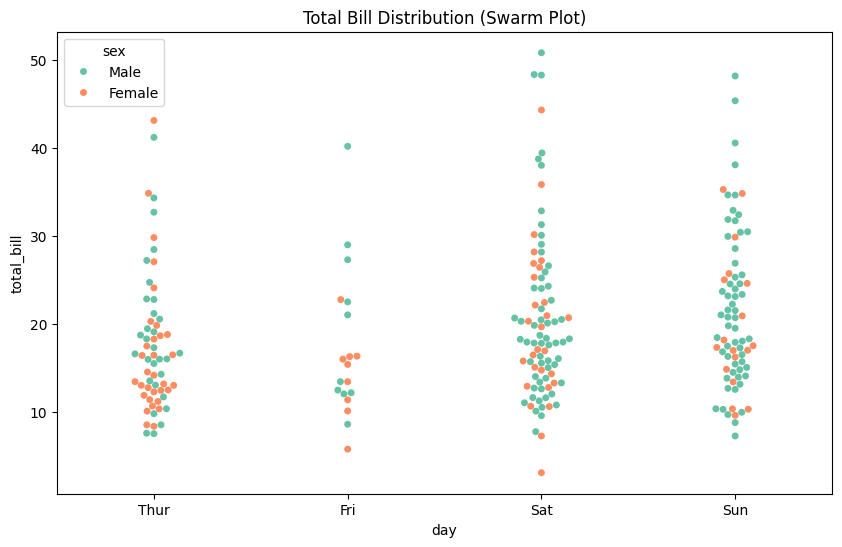

In [4]:
# Bar Plot with confidence intervals
sns.barplot(data=tips, x='day', y='total_bill', estimator=np.mean, palette='coolwarm')
# data=tips: use the tips dataset
# x='day': categorical variable (groups) - creates one bar per day (Thur, Fri, Sat, Sun)
# y='total_bill': numerical variable to aggregate - values to calculate average from
# estimator=np.mean: aggregation function - calculates MEAN/average for each day
#   (could also use: np.median, np.sum, np.std, etc.)
# palette='coolwarm': color scheme - gradient from cool (blue) to warm (red/orange)

# What the plot shows:
# - Bar height: Average total bill for each day
# - Error bars (black lines): 95% confidence intervals
#   - Show the RANGE where we're confident the TRUE average lies
#   - Longer bar = higher range = larger uncertainty = higher variability
#   - Shorter bar = lower range = smaller uncertainty = lower variability
# - Can compare which days have higher/lower average spending
# - Can assess certainty/variability in estimates

plt.title('Average Total Bill by Day')
plt.show()

# Count Plot
plt.figure(figsize=(10, 6))  # Create new figure
sns.countplot(data=tips, x='day', palette='pastel')
# x='day': categorical variable to count
# Automatically counts how many times each category appears
# Bar height = number of occurrences (frequency) for that day
# No y parameter needed - it counts automatically
# palette='pastel': soft color scheme

# What the plot shows:
# - How many customers visited on each day
# - Bar height = count/frequency (e.g., Thursday had 62 customers)
# - Perfect for categorical data distribution
# - No error bars (just raw counts, not estimates)

plt.title('Number of Customers per Day')
plt.show()

# Strip Plot
plt.figure(figsize=(10, 6))  # Create new figure
sns.stripplot(data=tips, x='day', y='total_bill', hue='sex', palette='Set1')
# x='day': categorical variable - groups data by day
# y='total_bill': numerical variable - each dot represents one bill amount
# hue='sex': split by gender - Male=one color, Female=another color
# palette='Set1': bright color scheme
# Shows EVERY individual data point as a dot (unlike bar plot which shows averages)

# What the plot shows:
# - Each dot = one customer's bill (all raw data visible)
# - Dots stacked vertically for each day
# - Color distinguishes Male vs Female customers
# - Can see:
#   - Distribution/spread of bills on each day
#   - Outliers (dots far from cluster)
#   - Gender differences in spending
# - Note: Dots may overlap (hard to see exact count)
plt.title('Total Bill Distribution by Day and Gender')
plt.show()

# Swarm Plot (shows all points without overlap)
plt.figure(figsize=(10, 6))  # Create new figure
sns.swarmplot(data=tips, x='day', y='total_bill', hue='sex', palette='Set2')
# Similar to strip plot BUT dots are arranged to avoid overlap
# x='day': categorical groups
# y='total_bill': numerical values - each dot is one observation
# hue='sex': color by gender
# palette='Set2': muted color scheme

# What the plot shows:
# - Each dot = one customer's bill (like strip plot)
# - Dots spread horizontally to AVOID OVERLAP (key difference!)
# - Easier to see individual points and count them
# - Width of swarm = density (wider = more data points at that value)
# - Can see:
#   - Exact distribution shape
#   - All individual values
#   - Concentration of data (where dots cluster)
#   - Gender patterns
# - Better than strip plot when you have many overlapping points
# - Warning: Can be slow with large datasets (>1000 points)

plt.title('Total Bill Distribution (Swarm Plot)')
plt.show()

### 3.3 Relational Plots

Relational plots show relationships between two or more numerical variables.

**Types:**
- `sns.scatterplot()` - Scatter plot
- `sns.lineplot()` - Line plot with confidence intervals
- `sns.relplot()` - Figure-level relational plot

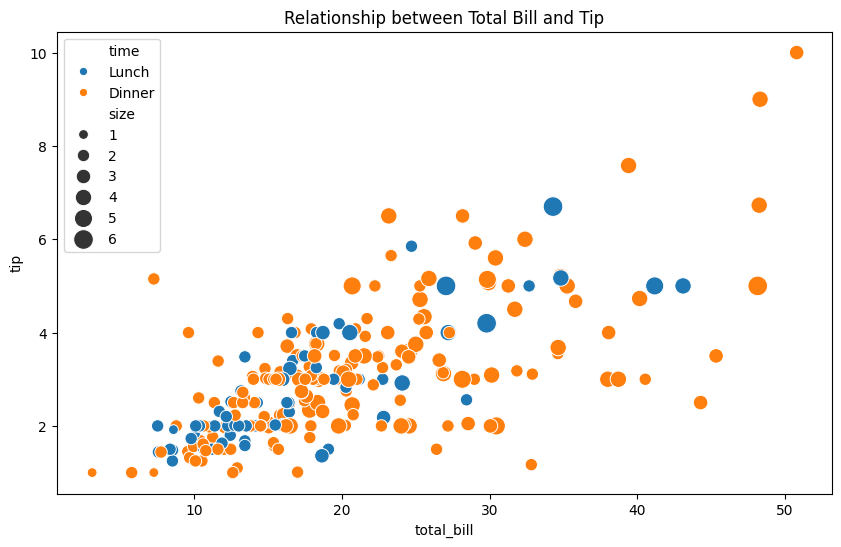

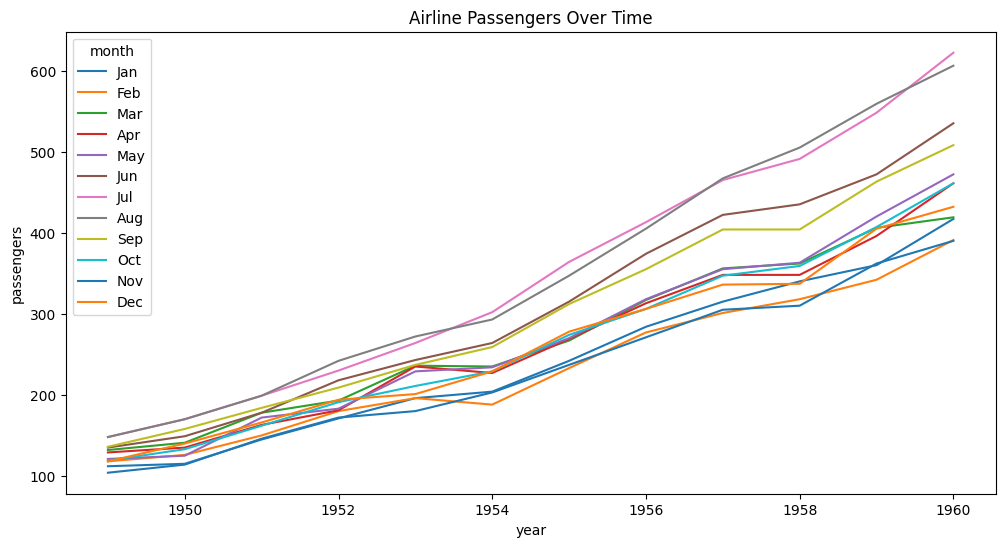

In [ ]:
# Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', size='size', sizes=(50, 200))
# size='size' means that the scatter plot will use a column named 'size' from the tips  dataframe to determine the size of each data point.
plt.title('Relationship between Total Bill and Tip')
plt.show()

# Line Plot with confidence interval
flights = sns.load_dataset('flights')
plt.figure(figsize=(12, 6))
sns.lineplot(data=flights, x='year', y='passengers', hue='month', palette='tab10')
plt.title('Airline Passengers Over Time')
plt.show()

### 3.4 Heatmap

Heatmaps display data as a color-coded matrix where **color intensity represents values** - darker colors = higher values, lighter colors = lower values.

Heatmap shows correlation between columns = 
How one column's values relate to another column's values

**Syntax:**
- `sns.heatmap(data)` - Create heatmap

**Common Parameters:**
- `annot=True` - Show numerical values inside cells
- `cmap='coolwarm'` - Color palette (blue=low, white=middle, red=high)
- `linewidths=0.5` - Border width between cells
- `fmt='.2f'` - Number format (e.g., '.2f' = 2 decimals)
- `vmin/vmax` - Set min/max values for color scale
- `cbar=True` - Show color legend bar

---

#### **How to Read a Heatmap:**

**Basic Structure:**
```
A grid where each cell has a color representing a value

           Feature A  Feature B  Feature C
Feature A    [cell]     [cell]     [cell]
Feature B    [cell]     [cell]     [cell]  
Feature C    [cell]     [cell]     [cell]
```

---

#### **3 Simple Steps:**

**Step 1: Find the Cell**
- Pick a row (y-axis)
- Pick a column (x-axis)
- Look where they intersect

**Step 2: Read the Color**
- **Dark/Intense color** = High value
- **Light/Pale color** = Low value
- Check the **color bar** (legend) to see exact value range

**Step 3: Interpret the Value**
- The number in the cell (if annot=True) or color intensity tells you the relationship strength

---

#### **Example - Correlation Heatmap:**

**What it shows:** How strongly variables are related (-1 to +1)
```
                total_bill    tip     size
total_bill        1.00       0.68    0.60
tip               0.68       1.00    0.49
size              0.60       0.49    1.00

Color scale: 🔵 Blue (-1) → ⚪ White (0) → 🔴 Red (+1)
```

**How to read it:**

1. **Find "total_bill" row and "tip" column → 0.68 (Orange/Red)**
   - Meaning: Strong positive correlation
   - Translation: "Higher bills = Higher tips"

2. **Find "tip" row and "size" column → 0.49 (Light Orange)**
   - Meaning: Moderate positive correlation
   - Translation: "Larger groups = Somewhat higher tips"

3. **Diagonal (all 1.00, Dark Red):**
   - Meaning: Perfect correlation
   - Translation: "Each variable perfectly matches itself"

---

#### **Quick Visual Guide:**

**Color Meanings:**
```
Correlation Heatmap (coolwarm):
🔴 Dark Red (0.8 to 1.0)    = Strong positive (both increase together)
🟠 Orange (0.5 to 0.8)      = Moderate positive
⚪ White (near 0)           = No relationship
🔵 Light Blue (-0.5 to 0)   = Moderate negative
🔵 Dark Blue (-1.0 to -0.5) = Strong negative (one up, other down & visa verca)
```

**Pattern Recognition:**
- **Diagonal line of dark colors** = Variables vs themselves (always perfect)
- **Hot spot (cluster of intense colors)** = Group of related variables
- **Symmetric pattern** = Same values mirrored (A→B = B→A)

---

#### **Summary:**

| Element | What It Shows |
|---------|---------------|
| **Cell position** | Which two variables are being compared |
| **Cell color** | Strength/value of relationship |
| **Color bar** | Legend showing what colors mean |
| **Numbers (if annot=True)** | Exact values |

**Think of it as:** A colored table where hot colors = high values, cool colors = low values!

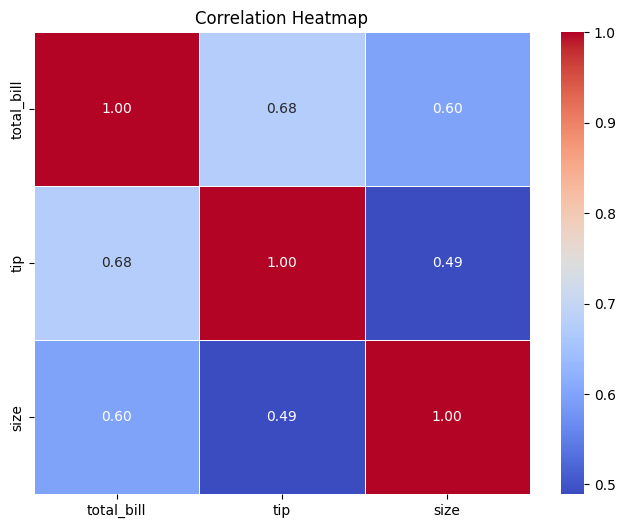

In [6]:
# Correlation Heatmap
# Create correlation matrix
corr = tips[['total_bill', 'tip', 'size']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### 3.5 Pair Plot

Pair plots show pairwise relationships between multiple variables in a dataset. Creates a grid of scatter plots and histograms.

**Syntax:**
- `sns.pairplot(df)` - Create pair plot for all numerical columns

**Use Case:**
- Quickly explore relationships between all variables
- Identify correlations and patterns
- **Shows all data points plotted for every pair of variables**
- Useful in exploratory data analysis (EDA)

#### **What is a Pair Plot?**

A **pair plot** is a grid that shows:
- **Every variable plotted against every other variable**
- All possible scatter plot combinations in one view
- Distribution of each variable on the diagonal

Think of it as: **"Compare everything with everything, all at once"**

#### **Quick Interpretation Guide:**

**Diagonal (Density/KDE plots):**
- Shows **distribution** of each single variable
- Peak = most common values
- Shape reveals: normal, skewed, bimodal patterns
- Hegith = frequency / density 
- X-axis represent the actual vlaue, we read the x-axis where we get a peak in the freq to know the most common value
- ex: x-axis = petal-width. Peak @4.5 cm (x-axis). Therefore, most common petal width for this flower is 4.5 cm

**Off-Diagonal (Scatter plots):**
- Shows **relationship** between two variables
- **Diagonal line pattern (/)** = Positive correlation (both increase together)
- **Opposite diagonal (\)** = Negative correlation (one up, other down)
- **Random scatter** = No correlation (independent variables)
- **Tight cluster** = Strong relationship
- **Loose scatter** = Weak relationship

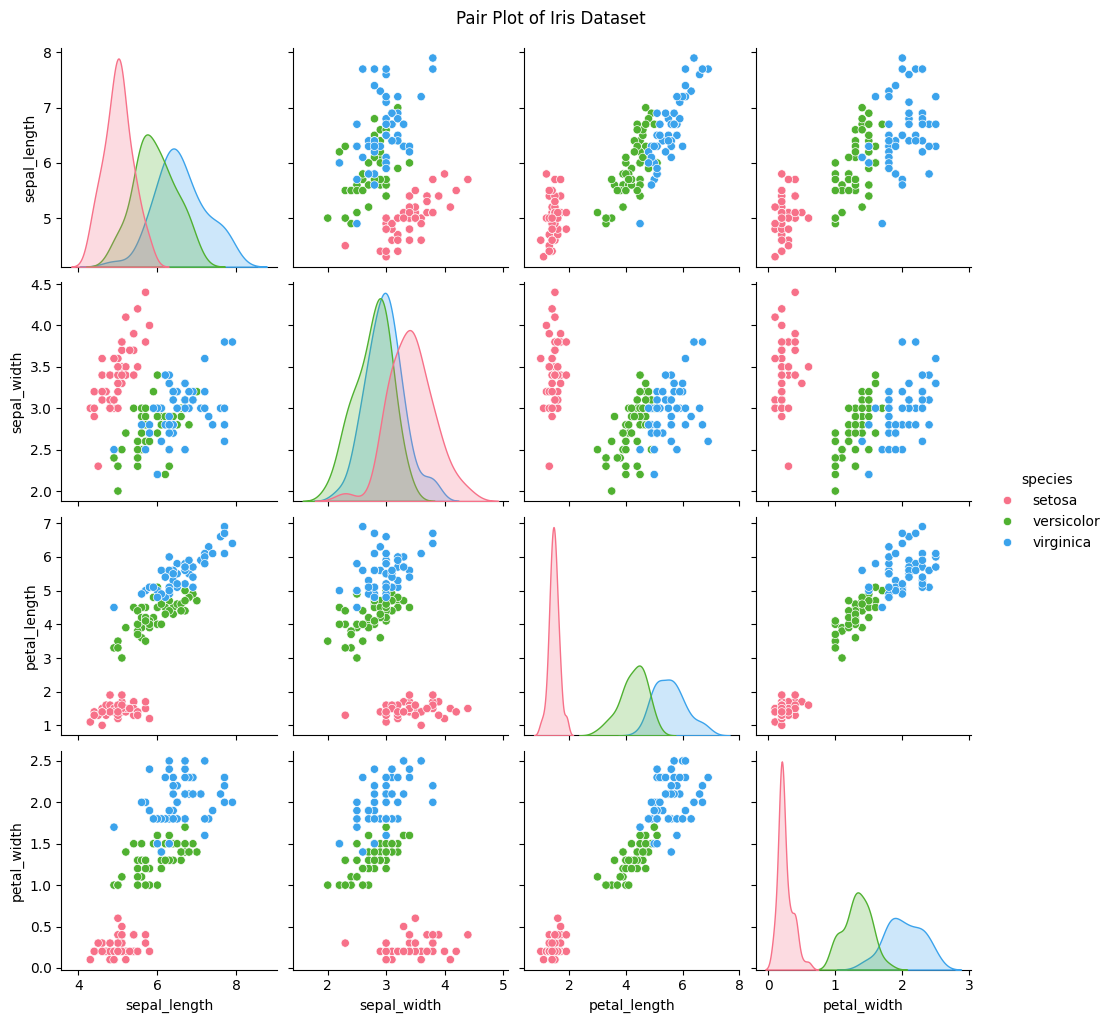

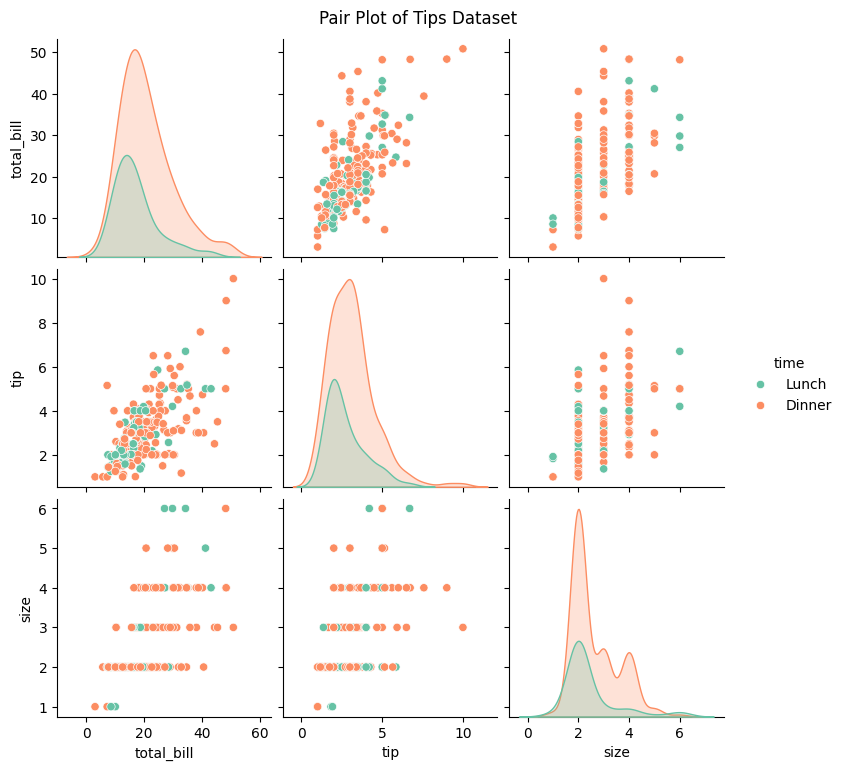

In [7]:
# Pair Plot
iris = sns.load_dataset('iris')  # Famous iris dataset

sns.pairplot(iris, hue='species', palette='husl')
plt.suptitle('Pair Plot of Iris Dataset', y=1.02)
plt.show()

# Pair Plot with specific columns
sns.pairplot(tips, vars=['total_bill', 'tip', 'size'], hue='time', palette='Set2')
plt.suptitle('Pair Plot of Tips Dataset', y=1.02)
plt.show()

### 3.6 Seaborn Styles and Themes

Seaborn provides built-in themes to quickly change the appearance of your plots.

**Available Styles:**
- `darkgrid` - Dark background with white grid
- `whitegrid` - White background with gray grid
- `dark` - Dark background without grid
- `white` - White background without grid
- `ticks` - White background with ticks

**Color Palettes:**
- `deep`, `muted`, `pastel`, `bright`, `dark`, `colorblind`
- `Set1`, `Set2`, `Set3`, `Paired`, `tab10`
- `viridis`, `plasma`, `inferno`, `magma`, `cividis`

C:\Users\asus\AppData\Local\Temp\ipykernel_55568\2255654912.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tips, x='day', y='total_bill', palette='Set2')


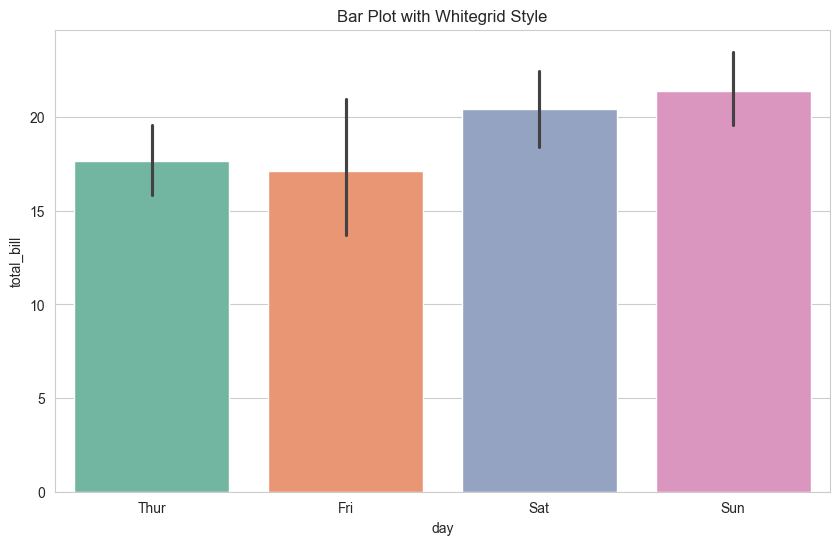

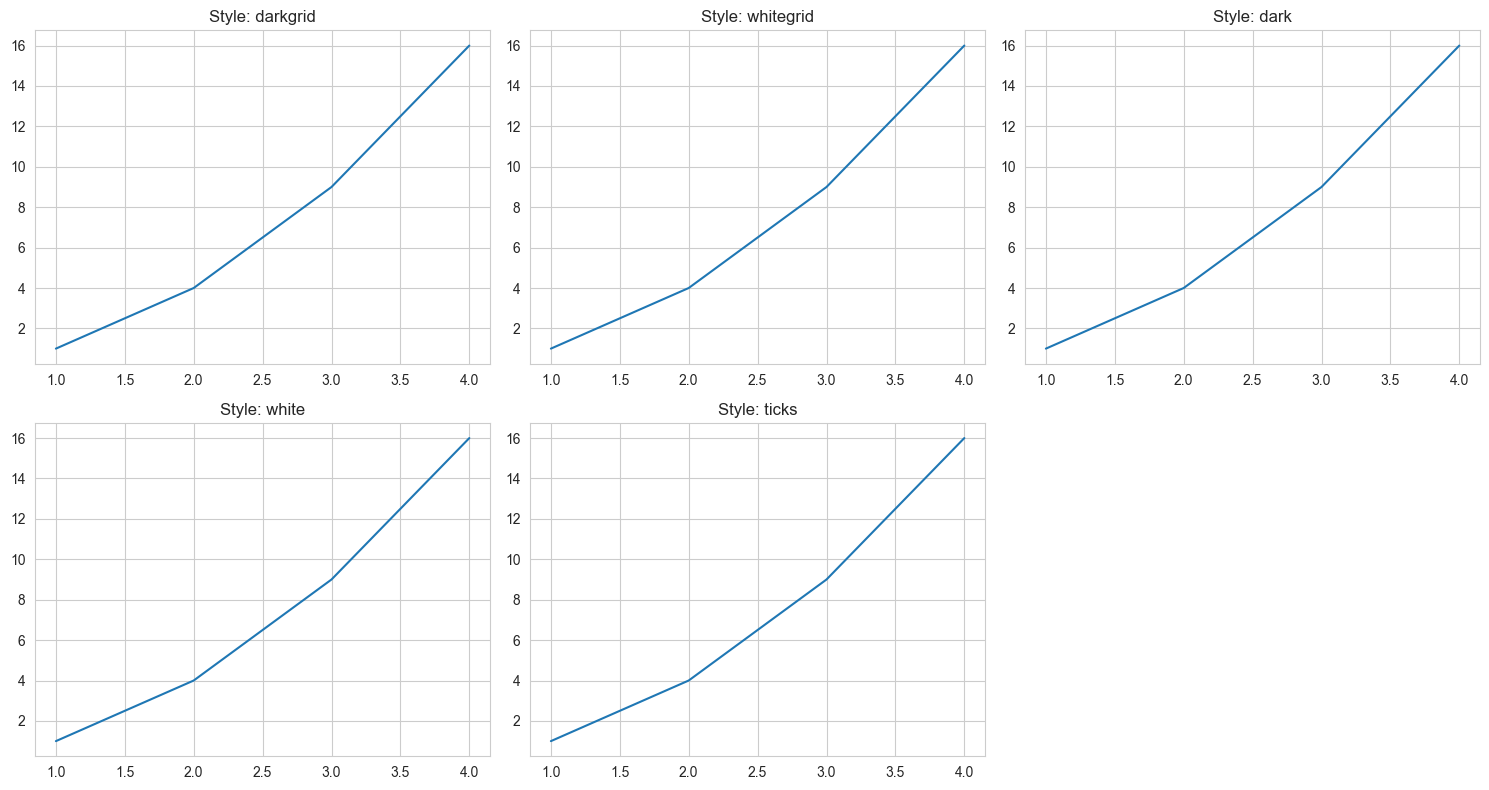

In [8]:
# Set style
sns.set_style('whitegrid')

plt.figure(figsize=(10, 6))
sns.barplot(data=tips, x='day', y='total_bill', palette='Set2')
plt.title('Bar Plot with Whitegrid Style')
plt.show()

# Different styles comparison
styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, style in enumerate(styles):
    sns.set_style(style)
    plt.sca(axes[i])
    sns.lineplot(x=[1, 2, 3, 4], y=[1, 4, 9, 16])
    axes[i].set_title(f'Style: {style}')

axes[5].axis('off')  # Hide the last empty subplot
plt.tight_layout()
plt.show()

# Reset to default
sns.set_style('darkgrid')